## **IMPORT NECESSARY LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

Loading in the data.

In [2]:
df = pd.read_excel("./merged_output_cleaned.xlsx")

df.head()


,year,immigrant,type of work,education,both sexes,men,women,gender,earnings,wages_salary,total_income
0,2018,Immigrant,Full-time,Less than high school,0.0,0.0,0.0,Female,4158.148734,3652.452532,21578.401899
1,2018,Immigrant,Full-time,Less than high school,0.0,0.0,0.0,Male,15309.529148,14325.448430,36995.739910
2,2018,Immigrant,Full-time,Less than high school,0.0,0.0,0.0,Female,4158.148734,3652.452532,21578.401899
3,2018,Immigrant,Full-time,Less than high school,0.0,0.0,0.0,Male,15309.529148,14325.448430,36995.739910
4,2018,Immigrant,Full-time,Less than high school,0.0,0.0,0.0,Female,4158.148734,3652.452532,21578.401899


**Defining the Numeric and Categorical columns.**

In [3]:
numeric_cols = ["both sexes", "men", "women",
                "earnings", "wages_salary", "total_income"]

In [4]:
categorical_cols = ["year", "immigrant", "type of work",
                    "education", "gender"]

**Summary Statistics for the Numeric Columns.**

In [5]:
df[numeric_cols].describe()

,both sexes,men,women,earnings,wages_salary,total_income
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000
mean,16.562333,14.650429,13.588619,30690.894398,29009.988827,49707.386489
std,10.634964,13.169453,10.999202,20003.351272,19073.888163,20167.370650
min,0.000000,0.000000,0.000000,3922.711670,3614.759725,19521.143474
25%,14.000000,0.000000,0.000000,14249.748744,13810.093897,35198.032070
50%,18.000000,17.000000,16.500000,27005.960854,26153.461880,43751.111407
75%,23.000000,24.000000,21.000000,41568.495763,39301.271186,59582.118644
max,42.700000,45.700000,40.900000,84021.577446,79098.683633,111537.297060


This table summarizes the central tendency and spread of key numeric variables.

**Frequency count for categorical Distrbution.**

In [6]:
for col in categorical_cols:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts().sort_index() if col == "year"
          else df[col].value_counts())


Value Counts for year:
year
2018    840
2019    840
2020    840
2021    840
2022    840
Name: count, dtype: int64

Value Counts for immigrant:
immigrant
Immigrant                         3500
Born in Canada (non-immigrant)     700
Name: count, dtype: int64

Value Counts for type of work:
type of work
Full-time    2100
Part-time    2100
Name: count, dtype: int64

Value Counts for education:
education
Less than high school                   1200
Postsecondary certificate or diploma    1200
University degree                       1200
High school diploma                      600
Name: count, dtype: int64

Value Counts for gender:
gender
Female    2100
Male      2100
Name: count, dtype: int64


The counts shows how workers are distributed across the various education levels, immigrant status, gender, type of work and years. This gives an overview of the data we are working with.

## **1. UNIVARIATE ANALYSIS**

**1.1. Wage Distribution.**

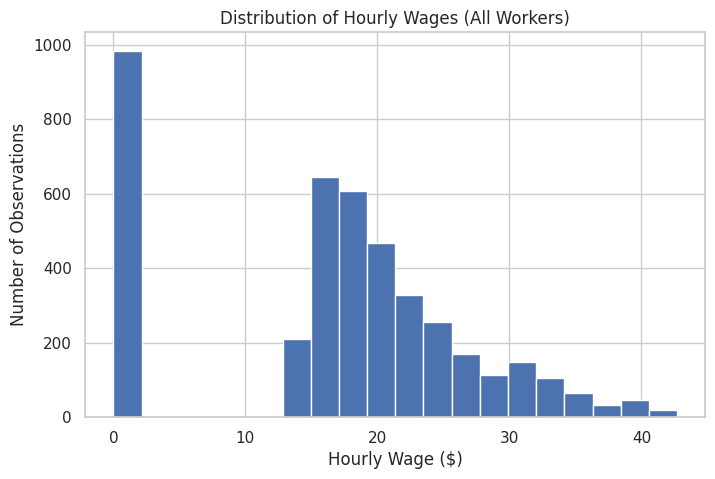

In [7]:
plt.figure(figsize=(8,5))
df["both sexes"].hist(bins=20)
plt.title("Distribution of Hourly Wages (All Workers)")
plt.xlabel("Hourly Wage ($)")
plt.ylabel("Number of Observations")
plt.show()

This chart shows the distribution of hourly wages for all workers and also helps us see if the distibution is skewed.

**1.2. Income Distribution (Total Annual Income)**

In [26]:
df.groupby("education")["total_income"].mean().sort_values()

/tmp/ipython-input-1571555161.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("education")["total_income"].mean().sort_values()


,total_income
education,
Less than high school,29622.570452
High school diploma,38374.615531
Postsecondary certificate or diploma,51309.927014
University degree,73856.047481


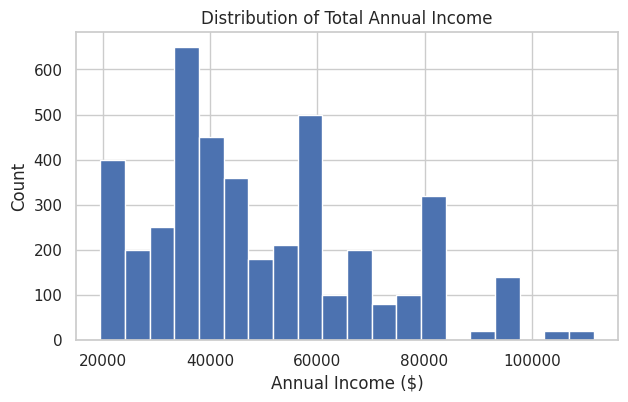

In [8]:
plt.figure(figsize=(7,4))
df["total_income"].hist(bins=20)
plt.title("Distribution of Total Annual Income")
plt.xlabel("Annual Income ($)")
plt.ylabel("Count")
plt.show()

This chart helps to identify income inequality, skewness and possible outliers.

**1.3. Distribution of Earnings.**

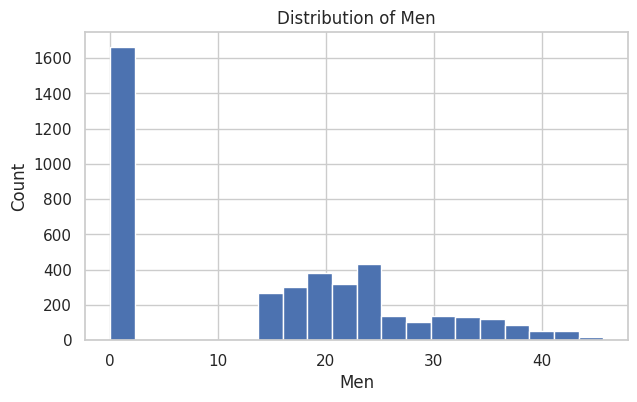

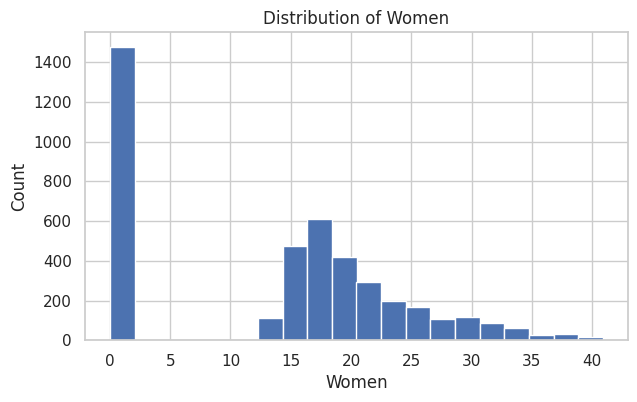

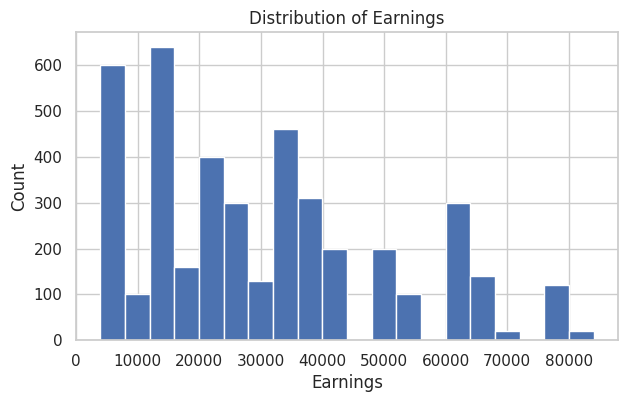

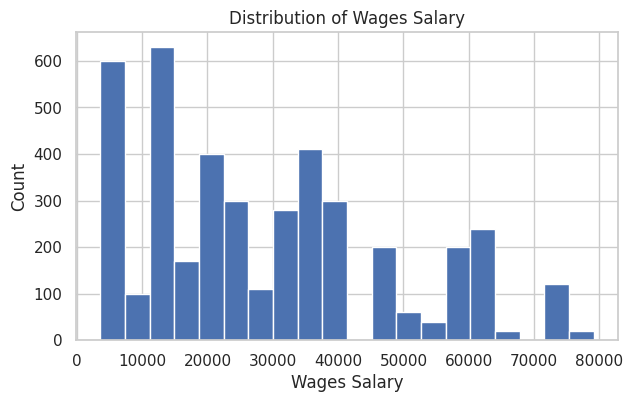

In [9]:
for col in ["men", "women", "earnings", "wages_salary"]:
    plt.figure(figsize=(7,4))
    df[col].hist(bins=20)
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel("Count")
    plt.show()

**1.4. Sample size for each year in the dataset.**

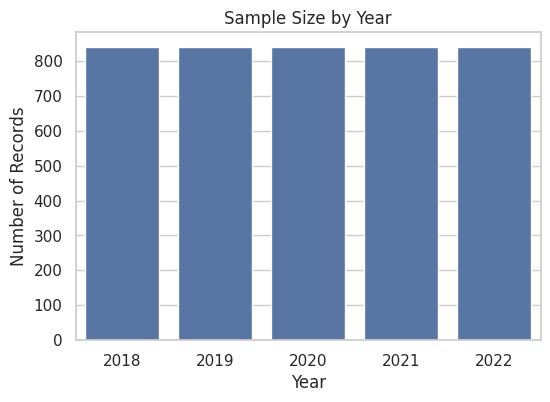

In [10]:
plt.figure(figsize=(6,4))
order_year = sorted(df["year"].unique())
sns.countplot(x="year", data=df, order=order_year)
plt.title("Sample Size by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.show()

This chart confirms that each year has the same sample size in this daatset, to avoid bias.

**1.5. Distribution of immigration status in the population.**

In [11]:
df["immigrant"].value_counts()

,count
immigrant,
Immigrant,3500
Born in Canada (non-immigrant),700


The dataset contains a much higher number of immigrant observations because the CIS microdata contributes individual-level survey records, while the education dataset contributes group-level aggregates.

As a result, the merged dataset reflects sampling structure, not the real population proportions in Ontario.
To avoid misleading interpretation, this variable is summarized in text only rather than visualized as a bar chart.

**1.6. Distribution based on the type of work.**

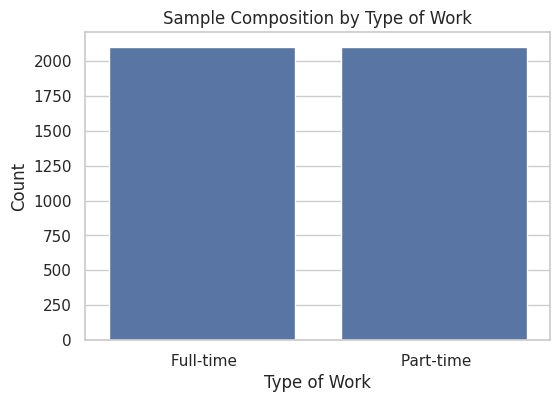

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="type of work", data=df)
plt.title("Sample Composition by Type of Work")
plt.xlabel("Type of Work")
plt.ylabel("Count")
plt.show()

This chart shows that we have equal representation of the full-time and part-time jobs.

**1.7. Distribution based on the education levels.**

/tmp/ipython-input-3106960072.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


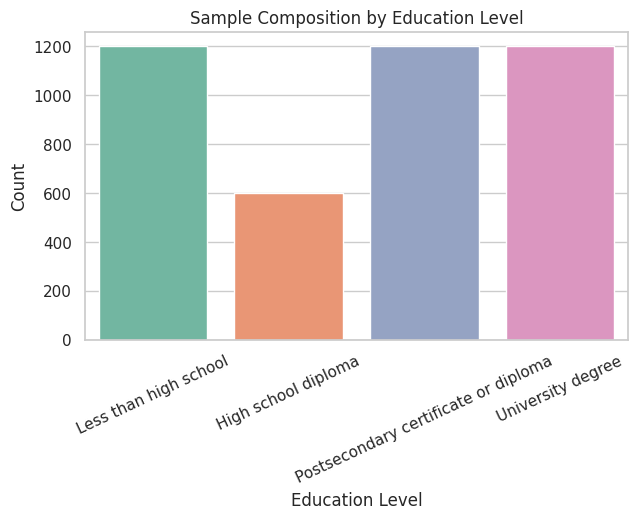

In [13]:
plt.figure(figsize=(7,4))

education_order = [
    "Less than high school",
    "High school diploma",
    "Postsecondary certificate or diploma",
    "University degree"
]

sns.countplot(
    x="education",
    data=df,
    order=education_order,
    palette="Set2"
)

plt.title("Sample Composition by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=25)
plt.show()


This chart shows an uneven count of education groups in the dataset with "High School diploma" having fewer records.
This is happening as a result of merging aggregated wage tables(Education Level) and the microdata(CIS).

**1.8. Distribution by Gender.**

/tmp/ipython-input-1341105662.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


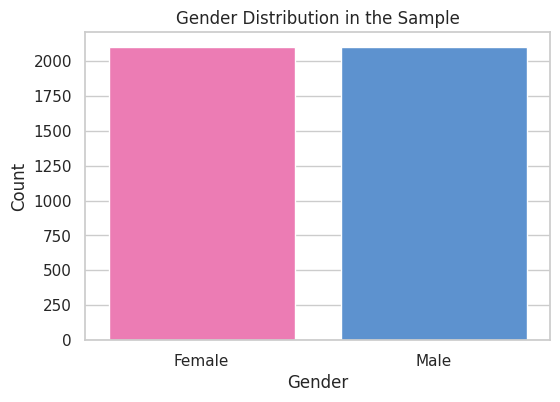

In [14]:
plt.figure(figsize=(6,4))

gender_palette = {
    "Male": "#4A90E2",
    "Female": "#FF69B4"
}

sns.countplot(
    x="gender",
    data=df,
    palette=gender_palette
)

plt.title("Gender Distribution in the Sample")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


This chart shows that we have balanced gender, which could be used to compare wages between Men and Women.

## **Overall Finding from my Univariate Analysis.**
- Annual incomes show a right-skewed shape, with University graduates getting the highest pay.
- Hourly wages shows a right-skewed distribution with fewer workers earning extremely high pay.

## **2. BIVARIATE ANALYSIS**

**2.1. Average hourly Wage by Education level.**

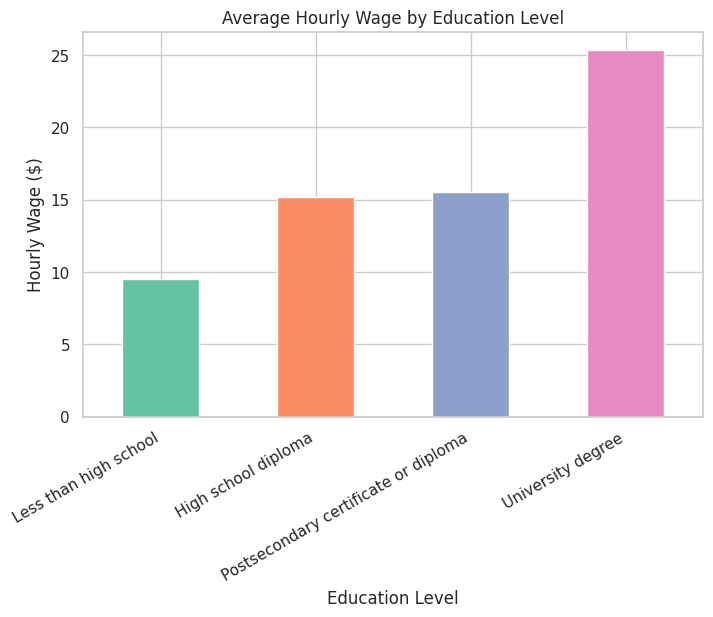

In [15]:
edu_means = df.groupby("education")["both sexes"].mean().sort_values()

color_map = {
    "Less than high school": "#66c2a5",
    "High school diploma": "#fc8d62",
    "Postsecondary certificate or diploma": "#8da0cb",
    "University degree": "#e78ac3"
}
edu_order = edu_means.index
colors = [color_map.get(e, "#999999") for e in edu_order]

plt.figure(figsize=(8,5))
edu_means.plot(kind="bar", color=colors)
plt.title("Average Hourly Wage by Education Level")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Education Level")
plt.xticks(rotation=30, ha="right")
plt.show()

This chart shows the average hourly wage for each education level. It shows how wages increases as education moves from less than high school to university degree.

**2.2. Average Hourly Wage by Immigrant Status.**

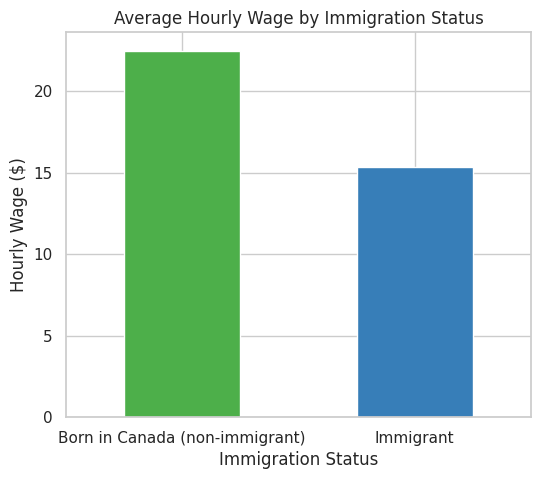

In [16]:
imm_means = df.groupby("immigrant")["both sexes"].mean()

plt.figure(figsize=(6,5))
imm_means.plot(kind="bar", color=["#4daf4a", "#377eb8"])
plt.title("Average Hourly Wage by Immigration Status")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Immigration Status")
plt.xticks(rotation=0)
plt.show()

This chart compares the average hourly wage between immigrants and Canadian born. It shows the wage gap that is associated with the immigration status.

**2.3. Average Wage by Gender.**

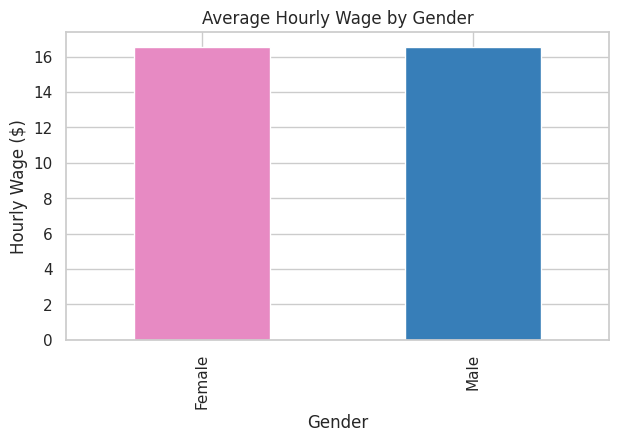

In [17]:
plt.figure(figsize=(7,4))
df.groupby("gender")["both sexes"].mean().plot(
    kind="bar",
    color=["#e78ac3", "#377eb8"]
)
plt.title("Average Hourly Wage by Gender")
plt.xlabel("Gender")
plt.ylabel("Hourly Wage ($)")
plt.show()

This chart shows if theres a wage gap in Ontario for this Sample dataset.

The both sexes column used here is a wage measure and is not split by gender so it can't show a true gender wage gap.

**2.4. Average hourly wage by type of work.**

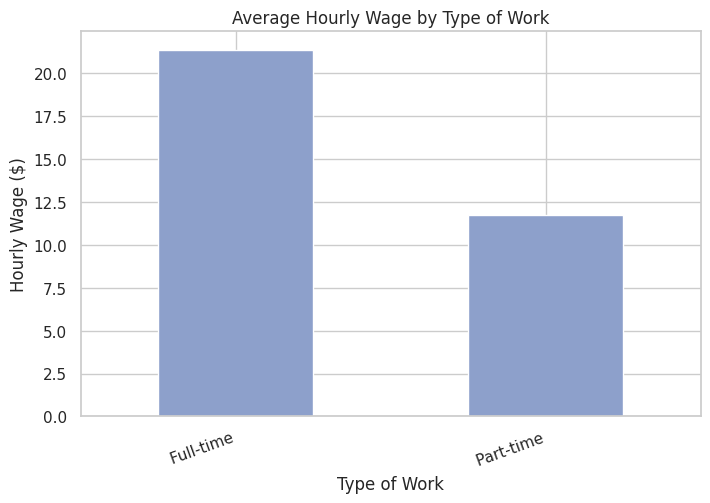

In [18]:
plt.figure(figsize=(8,5))
df.groupby("type of work")["both sexes"].mean().plot(kind="bar", color="#8da0cb")
plt.title("Average Hourly Wage by Type of Work")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Type of Work")
plt.xticks(rotation=20, ha="right")
plt.show()

This chart shows the differences between full time and part time works.

**2.5. Education and Immigrant Status.**

/tmp/ipython-input-3941690670.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


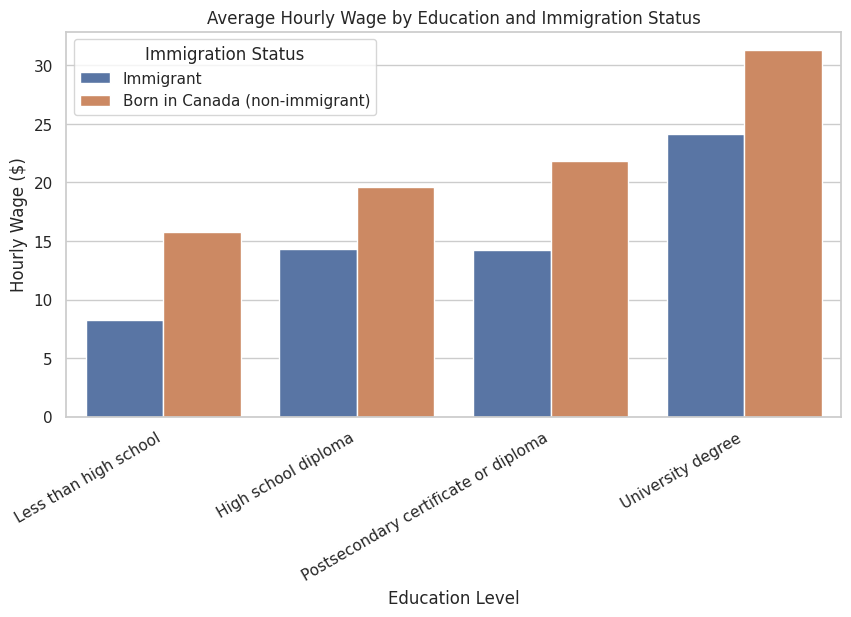

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x="education",
    y="both sexes",
    hue="immigrant",
    estimator="mean",
    ci=None
)
plt.title("Average Hourly Wage by Education and Immigration Status")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Education Level")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Immigration Status")
plt.show()

This chart shows the average hourly wage by education level, which is then seperated by immigrant status. It shows whether immigrants earns less even at the same education level.

## **Overall Finding from my Bivariate Analysis**
- Wage increases consistently based on the education status.
- Non- Immigrants earns more than Immigrants across all education level.
- Full time workerss earn more than Part time workers, which is true because there's a difference in the minimum wage for both type of work.

## **3. MULTIVARIATE**

**3.1. Wage Trend Over Time by Immigration Status.**

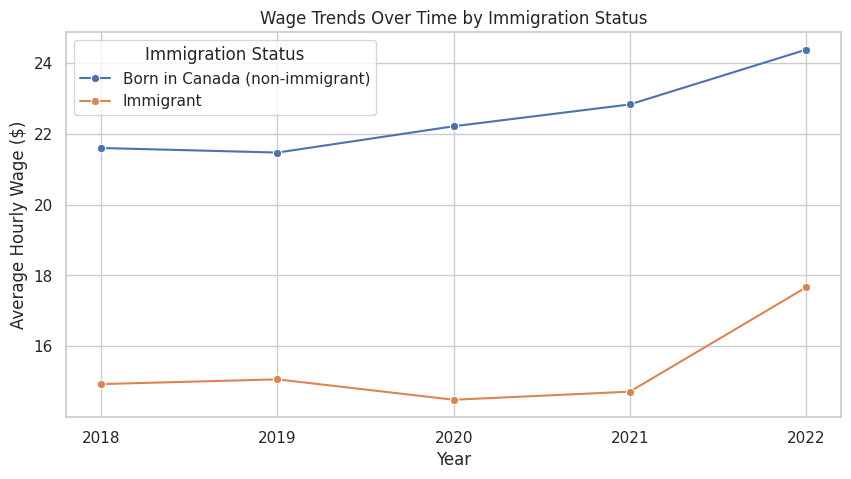

In [20]:
trend_df = (
    df.groupby(["year", "immigrant"], as_index=False)["both sexes"]
      .mean()
)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=trend_df,
    x="year",
    y="both sexes",
    hue="immigrant",
    marker="o"
)
plt.title("Wage Trends Over Time by Immigration Status")
plt.ylabel("Average Hourly Wage ($)")
plt.xlabel("Year")
plt.xticks(sorted(df["year"].unique()))
plt.legend(title="Immigration Status")
plt.show()

This chart shows if the wage gaps between Immigrants and Non-Immigrants is reducing or widening over time(2018-2022).

**3.2. Education and Immigrant (Average hourly Wage).**

/tmp/ipython-input-2489051061.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


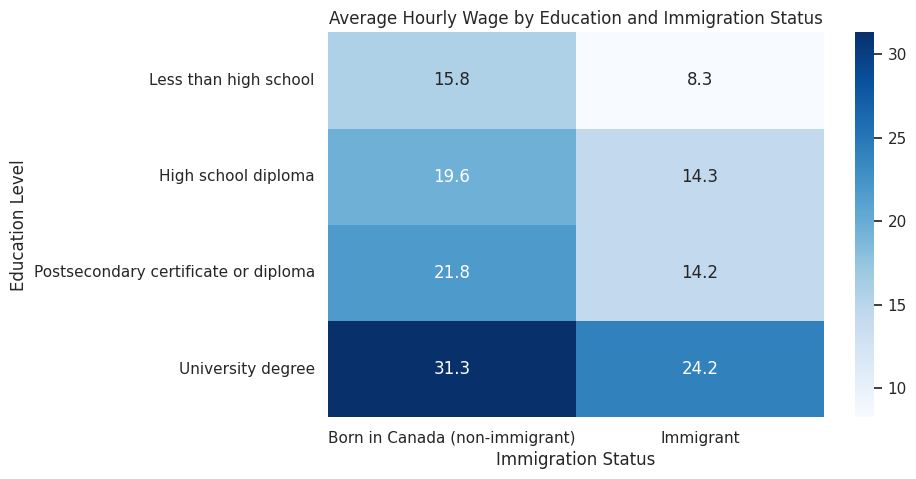

In [21]:
edu_order = [
    "Less than high school",
    "High school diploma",
    "Postsecondary certificate or diploma",
    "University degree"
]

df["education"] = pd.Categorical(df["education"], categories=edu_order, ordered=True)


pivot = df.pivot_table(
    values="both sexes",
    index="education",
    columns="immigrant",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Average Hourly Wage by Education and Immigration Status")
plt.xlabel("Immigration Status")
plt.ylabel("Education Level")
plt.show()

This heatmap gives a two-dimensional comparison of averae hourly wages with respect to the different education levels and the immigration status.

The color intensity of the blue shade shows the concentration of how people are being paid with the Darker Shade being the category with higher wages and the lighter shade being the category with the lower wage.

**3.3. Annual Income Distribution by Education Level.**

/tmp/ipython-input-3280486417.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


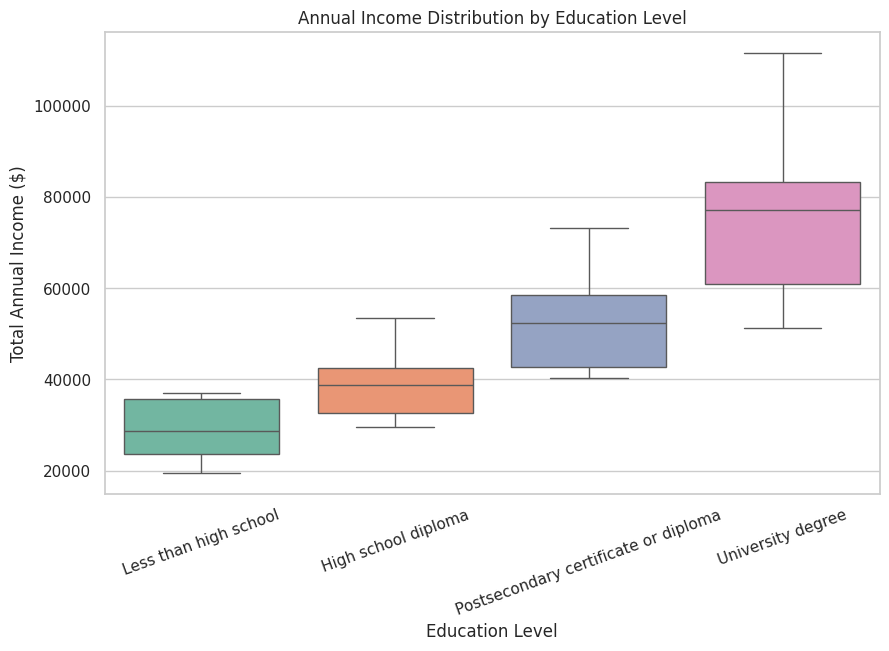

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="education",
    y="total_income",
    palette="Set2"
)
plt.title("Annual Income Distribution by Education Level")
plt.ylabel("Total Annual Income ($)")
plt.xlabel("Education Level")
plt.xticks(rotation=20)
plt.show()


This box plot shows that income increases with increase in education level.

##**Overall Finding from my Multivariate Analysis.**
Multivariate patterns shows that education improves wages for all groups(Immigrants or Non-Immigrants), even if Immigrants experience low returns at every education level.

Regardless of the increase in wage between 2018-2022, there's still a wage gap between bpth groups(immigrants and born in canada).